# Transfer Learning v2 – Research-First Vietnam Pipeline

### 🔧 Changelog v3.2 (Research Core):
1. ✅ **Giản lược feature về lõi hợp lệ**: ưu tiên calendar + weather cơ bản + target history, loại bỏ feature khó giải thích hoặc dễ gây lệch miền.
2. ✅ **Chuẩn hóa split theo thời gian**: tách train / validation / test cuối chuỗi để đánh giá đúng khả năng tổng quát hóa.
3. ✅ **Cố định precision ổn định**: ưu tiên FP32 trên GPU thay vì mixed precision không ổn định với RNN/TFT trong môi trường hiện tại.
4. ✅ **Sửa đánh giá và vẽ biểu đồ**: tách metric theo split và dùng logic an toàn hơn khi lấy prediction output.

*(Hãy chạy notebook theo thứ tự từ trên xuống)*

In [47]:
# ── Cell 1: Import ────────────────────────────────────────────────────────────
import os, json, shutil, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import r2_score

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

pl.seed_everything(42, workers=True)
torch.set_float32_matmul_precision('high')

config_path = Path('checkpoint/model_config_v2.json')
if config_path.exists():
    with open(config_path, 'r') as f:
        model_cfg = json.load(f)
    LOG_TRANSFORM = model_cfg.get('LOG_TRANSFORM', True)
    print(f'✅ Config loaded – LOG_TRANSFORM={LOG_TRANSFORM}')
else:
    LOG_TRANSFORM = True
    print('⚠️ model_config_v2.json not found, LOG_TRANSFORM=True')

CHECKPOINT_PATH = 'checkpoint/tft_v2_best.ckpt'
print(f'Pretrained: {CHECKPOINT_PATH} | Exists: {os.path.exists(CHECKPOINT_PATH)}')

INFO: Seed set to 42
INFO: Seed set to 42


[18:33:50] INFO     Seed set to 42                                   seed.py:57
✅ Config loaded – LOG_TRANSFORM=True
Pretrained: checkpoint/tft_v2_best.ckpt | Exists: True


In [48]:
# ── Cell 2: Load & xử lý dữ liệu Vietnam ─────────────────────────────────────
path_vn = Path('data/processed/VN_data/full_vietnam_monthly_merger.csv')
df_main = pd.read_csv(path_vn, sep=',')

if 'series' in df_main.columns:
    df_main['series'] = df_main['series'].astype(str).str.strip()
    df_main = df_main[~df_main['series'].str.casefold().eq('total generation')].copy()

df_vn = df_main.rename(columns={
    'generation_twh': 'generation_TWh',
    'precip_mean': 'precipitation',
    'solar_mean': 'solar',
    'humidity_mean': 'humidity',
    'temp_mean': 'temperature',
})

SPARSE_THRESHOLD = 0.60
raw_target = pd.to_numeric(df_vn['generation_TWh'], errors='coerce').fillna(0)
zero_ratio = pd.DataFrame({'series': df_vn['series'], 'raw_target': raw_target}).groupby('series')['raw_target'].apply(lambda s: (s == 0).mean())
sparse_series = zero_ratio[zero_ratio >= SPARSE_THRESHOLD].index.tolist()
if sparse_series:
    df_vn = df_vn[~df_vn['series'].isin(sparse_series)].copy()

df_vn['generation_TWh'] = pd.to_numeric(df_vn['generation_TWh'], errors='coerce').fillna(0).replace(0, 1e-4).clip(lower=1e-4)

if LOG_TRANSFORM:
    df_vn['generation_TWh'] = np.log1p(df_vn['generation_TWh'])

df_vn['date'] = pd.to_datetime(df_vn['date'])
df_vn = df_vn.sort_values(['entity', 'series', 'date']).reset_index(drop=True)

min_date = df_vn['date'].min()
df_vn['time_idx'] = ((df_vn['date'].dt.year - min_date.year) * 12 + (df_vn['date'].dt.month - min_date.month)).astype(int)
df_vn['month'] = df_vn['date'].dt.month.astype(str)
df_vn['month_sin'] = np.sin(2 * np.pi * df_vn['date'].dt.month / 12.0)
df_vn['month_cos'] = np.cos(2 * np.pi * df_vn['date'].dt.month / 12.0)

basic_exo_cols = ['precipitation', 'solar', 'humidity', 'temperature']
for c in basic_exo_cols:
    if c in df_vn.columns:
        df_vn[c] = df_vn.groupby(['entity', 'series'])[c].transform(lambda x: x.ffill())
        median_c = pd.to_numeric(df_vn[c], errors='coerce').median()
        df_vn[c] = pd.to_numeric(df_vn[c], errors='coerce').fillna(median_c if pd.notna(median_c) else 0)
        q01, q99 = df_vn[c].quantile([0.01, 0.99])
        df_vn[c] = df_vn[c].clip(lower=q01, upper=q99)

# Đồng bộ với pretrain: tạo rolling weather từ quá khứ để giảm domain shift transfer.
weather_roll_specs = [
    ('precipitation', 'precip_roll6', 6),
    ('precipitation', 'precip_roll12', 12),
    ('temperature', 'temp_roll6', 6),
    ('temperature', 'temp_roll12', 12),
]
for base_col, roll_col, win in weather_roll_specs:
    if base_col in df_vn.columns:
        shifted_exo = df_vn.groupby(['entity', 'series'])[base_col].shift(1)
        df_vn[roll_col] = (
            shifted_exo.groupby([df_vn['entity'], df_vn['series']])
            .rolling(win, min_periods=1)
            .mean()
            .reset_index(level=[0, 1], drop=True)
        )

lag_features = [1, 2, 3, 4, 6, 9, 12]
for lag in lag_features:
    df_vn[f'target_lag_{lag}'] = df_vn.groupby(['entity', 'series'])['generation_TWh'].shift(lag)

for win in [3, 6, 12]:
    shifted = df_vn.groupby(['entity', 'series'])['generation_TWh'].shift(1)
    df_vn[f'target_roll_mean_{win}'] = (
        shifted.groupby([df_vn['entity'], df_vn['series']])
        .rolling(win, min_periods=1)
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )
    df_vn[f'target_roll_std_{win}'] = (
        shifted.groupby([df_vn['entity'], df_vn['series']])
        .rolling(win, min_periods=1)
        .std()
        .reset_index(level=[0, 1], drop=True)
    )

past_target = df_vn.groupby(['entity', 'series'])['generation_TWh'].shift(1)
df_vn['target_diff_1'] = past_target - past_target.groupby([df_vn['entity'], df_vn['series']]).shift(1)
df_vn['target_diff_3'] = past_target - past_target.groupby([df_vn['entity'], df_vn['series']]).shift(3)
df_vn['target_diff_6'] = past_target - past_target.groupby([df_vn['entity'], df_vn['series']]).shift(6)
df_vn['target_trend_3'] = df_vn['target_roll_mean_3'] - df_vn['target_roll_mean_6']
df_vn['target_trend_6'] = df_vn['target_roll_mean_6'] - df_vn['target_roll_mean_12']

feature_fill_cols = [
    c for c in df_vn.columns
    if c.startswith('target_lag_')
    or c.startswith('target_roll_')
    or c.startswith('precip_roll')
    or c.startswith('temp_roll')
]
for c in feature_fill_cols:
    # Chỉ ffill để tránh leakage từ tương lai (không dùng bfill).
    df_vn[c] = df_vn.groupby(['entity', 'series'])[c].transform(lambda x: x.ffill())
    df_vn[c] = pd.to_numeric(df_vn[c], errors='coerce').fillna(0)

print(f'✅ Khởi tạo chuỗi thành công. Kích thước dữ liệu sau lọc: {len(df_vn)}')
print(f"✅ Đã tạo {len(feature_fill_cols)} feature động đồng bộ với pretrain")

✅ Khởi tạo chuỗi thành công. Kích thước dữ liệu sau lọc: 360
✅ Đã tạo 17 feature động đồng bộ với pretrain


In [49]:
# ── Cell 3: Tạo TimeSeriesDataSet ─────────────────────────────────────────────
# Ưu tiên đồng bộ feature-space với pretrain để tăng hiệu quả transfer.
max_encoder_length = 36
max_prediction_length = 6
batch_size = 32

USE_EXTENDED_TRANSFER_FEATURES = True

# Split ổn định hơn: Validation dài hơn để đánh giá đáng tin cậy hơn, Test vẫn giữ holdout gần nhất.
VAL_MONTHS = 12
TEST_MONTHS = 6

min_len = max_encoder_length + max_prediction_length + max_prediction_length
series_len = df_vn.groupby(['entity', 'series'])['time_idx'].nunique().reset_index(name='n')
valid_groups = series_len.loc[series_len['n'] >= min_len, ['entity', 'series']]
df_vn_valid = df_vn.merge(valid_groups, on=['entity', 'series'], how='inner').copy()
df_vn_valid = df_vn_valid.reset_index(drop=True)

if df_vn_valid.empty:
    raise ValueError('No series long enough!')

max_time_idx = int(df_vn_valid['time_idx'].max())
if (VAL_MONTHS + TEST_MONTHS) >= max_time_idx:
    raise ValueError('VAL_MONTHS + TEST_MONTHS quá lớn so với độ dài chuỗi.')

train_cutoff = max_time_idx - (VAL_MONTHS + TEST_MONTHS)
val_cutoff = max_time_idx - TEST_MONTHS

known_candidates = [
    'time_idx',
    'month_sin',
    'month_cos',
    'precipitation',
    'temperature',
]
unknown_candidates = [
    'generation_TWh',
    'target_roll_mean_3',
    'target_roll_mean_6',
    'target_roll_mean_12',
    'target_roll_std_3',
    'target_roll_std_6',
    'target_roll_std_12',
    'target_diff_1',
    'target_diff_3',
    'target_diff_6',
    'target_trend_3',
    'target_trend_6',
]

if USE_EXTENDED_TRANSFER_FEATURES:
    known_candidates += ['humidity', 'solar', 'precip_roll6', 'precip_roll12', 'temp_roll6', 'temp_roll12']

known_reals = [c for c in known_candidates if c in df_vn_valid.columns]
unknown_reals = [c for c in unknown_candidates if c in df_vn_valid.columns]

normalizer = GroupNormalizer(
    groups=['entity', 'series'],
    center=True,
)

training = TimeSeriesDataSet(
    df_vn_valid[lambda x: x.time_idx <= train_cutoff],
    time_idx='time_idx',
    target='generation_TWh',
    group_ids=['entity', 'series'],
    min_encoder_length=24,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=['entity', 'series'],
    time_varying_known_categoricals=['month'],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=normalizer,
    lags={'generation_TWh': [1, 2, 3, 6, 12]},
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation_df = df_vn_valid[lambda x: x.time_idx <= val_cutoff].copy()
test_df = df_vn_valid.copy()

validation = TimeSeriesDataSet.from_dataset(
    training,
    validation_df,
    min_prediction_idx=train_cutoff + 1,
    stop_randomization=True,
)

testset = TimeSeriesDataSet.from_dataset(
    training,
    test_df,
    min_prediction_idx=val_cutoff + 1,
    stop_randomization=True,
)

train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)
test_loader = testset.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

print(f'✅ Windows – train: {len(training)}, val: {len(validation)}, test: {len(testset)}')
print(f'✅ Split months – val: {VAL_MONTHS}, test: {TEST_MONTHS}')
print(f'✅ Cutoff – train<= {train_cutoff}, val<= {val_cutoff}, test> {val_cutoff}')
print(f'✅ USE_EXTENDED_TRANSFER_FEATURES={USE_EXTENDED_TRANSFER_FEATURES}')
print(f'✅ Known reals: {known_reals}')
print(f'✅ Unknown reals: {unknown_reals}')

✅ Windows – train: 125, val: 95, test: 65
✅ Split months – val: 12, test: 6
✅ Cutoff – train<= 53, val<= 65, test> 65
✅ USE_EXTENDED_TRANSFER_FEATURES=True
✅ Known reals: ['time_idx', 'month_sin', 'month_cos', 'precipitation', 'temperature', 'humidity', 'solar', 'precip_roll6', 'precip_roll12', 'temp_roll6', 'temp_roll12']
✅ Unknown reals: ['generation_TWh', 'target_roll_mean_3', 'target_roll_mean_6', 'target_roll_mean_12', 'target_roll_std_3', 'target_roll_std_6', 'target_roll_std_12', 'target_diff_1', 'target_diff_3', 'target_diff_6', 'target_trend_3', 'target_trend_6']


In [50]:
# ── Cell 4: Khởi tạo model & load pretrained ─────────────────────────────────
os.makedirs('checkpoint', exist_ok=True)
from pytorch_forecasting.metrics import MAE

accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
devices = 1
precision = 32
print(f'🚀 Transfer accelerator: {accelerator} | devices={devices} | precision={precision}')

# Dùng point-loss để tối ưu trực tiếp MAE/WAPE thay vì làm mượt theo quantile.
tft_vn = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=5e-5,
    hidden_size=128,
    attention_head_size=4,
    dropout=0.10,
    hidden_continuous_size=64,
    loss=MAE(),
    log_interval=20,
    reduce_on_plateau_patience=5,
    optimizer='adamw',
    weight_decay=1e-4,
    mask_bias=-1e4,
    output_size=1,
)

MIN_MATCH_RATIO = 0.85
STRONG_MATCH_RATIO = 0.95
n_t = n_m = p_t = p_m = 0
match_ratio = 0.0

if os.path.exists(CHECKPOINT_PATH):
    pretrained_dict = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)['state_dict']
    model_dict = tft_vn.state_dict()
    matched_dict = {
        k: v for k, v in pretrained_dict.items()
        if k in model_dict and v.shape == model_dict[k].shape
    }

    p_t = sum(v.numel() for v in model_dict.values())
    p_m = sum(v.numel() for v in matched_dict.values())
    n_t, n_m = len(model_dict), len(matched_dict)
    match_ratio = p_m / max(p_t, 1)

    print(f'🔁 Tensors: {n_m}/{n_t} ({n_m/max(n_t,1):.1%}) | Params: {p_m/1e3:.1f}k/{p_t/1e3:.1f}k ({match_ratio:.1%})')

    if match_ratio < MIN_MATCH_RATIO:
        raise RuntimeError(
            f'Checkpoint mismatch quá lớn ({match_ratio:.1%} < {MIN_MATCH_RATIO:.0%}). '
            'Dừng để tránh transfer sai cấu hình.'
        )

    model_dict.update(matched_dict)
    tft_vn.load_state_dict(model_dict)
else:
    raise FileNotFoundError(f'Không tìm thấy pretrained checkpoint: {CHECKPOINT_PATH}')

if match_ratio >= STRONG_MATCH_RATIO:
    FREEZE_STRATEGY = 'full_backbone_freeze'
else:
    FREEZE_STRATEGY = 'partial_backbone_freeze'

print(f'✅ Freeze strategy: {FREEZE_STRATEGY}')

🚀 Transfer accelerator: gpu | devices=1 | precision=32
🔁 Tensors: 803/806 (99.6%) | Params: 2121.1k/2122.1k (100.0%)
✅ Freeze strategy: full_backbone_freeze


In [51]:
# ── Cell 5: Stage 1 – Warm-up (frozen backbone) ───────────────────────────────
print('== STAGE 1: Warm-up (adaptive freeze) ==')

if FREEZE_STRATEGY == 'full_backbone_freeze':
    FREEZE_LAYERS = ['lstm_encoder', 'lstm_decoder', 'multihead_attn', 'post_attn_gate_norm']
else:
    FREEZE_LAYERS = ['multihead_attn', 'post_attn_gate_norm']

print(f"Stage 1 freeze layers: {FREEZE_LAYERS}")
for name, param in tft_vn.named_parameters():
    if any(f in name for f in FREEZE_LAYERS):
        param.requires_grad = False
    else:
        param.requires_grad = True

stage1_precision = precision

torch.backends.cudnn.enabled = False
torch.set_grad_enabled(True)
tft_vn.train()
if hasattr(tft_vn, 'lstm_encoder'):
    tft_vn.lstm_encoder.train()
if hasattr(tft_vn, 'lstm_decoder'):
    tft_vn.lstm_decoder.train()

tft_vn.hparams.learning_rate = 8e-6
cb_es_warmup = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=10, mode='min')
trainer_warmup = pl.Trainer(
    max_epochs=3,
    accelerator=accelerator,
    devices=devices,
    precision=stage1_precision,
    gradient_clip_val=0.5,
    num_sanity_val_steps=0,
    enable_model_summary=False,
    callbacks=[cb_es_warmup],
)
trainer_warmup.fit(tft_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)

tft_vn.hparams.learning_rate = 5e-5
torch.set_grad_enabled(True)
tft_vn.train()
if hasattr(tft_vn, 'lstm_encoder'):
    tft_vn.lstm_encoder.train()
if hasattr(tft_vn, 'lstm_decoder'):
    tft_vn.lstm_decoder.train()

cb_es_s1 = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=10, mode='min')
cb_ckpt_s1 = ModelCheckpoint(
    dirpath='checkpoint',
    monitor='val_loss',
    mode='min',
    filename='tft_vn_s1-{epoch:02d}-{val_loss:.4f}',
    save_top_k=1,
    save_last=True,
)
trainer_s1 = pl.Trainer(
    max_epochs=16,
    accelerator=accelerator,
    devices=devices,
    precision=stage1_precision,
    gradient_clip_val=0.5,
    num_sanity_val_steps=0,
    callbacks=[cb_es_s1, cb_ckpt_s1],
    enable_model_summary=False,
)
trainer_s1.fit(tft_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)

== STAGE 1: Warm-up (adaptive freeze) ==
Stage 1 freeze layers: ['lstm_encoder', 'lstm_decoder', 'multihead_attn', 'post_attn_gate_norm']


Output()

Output()

In [52]:
# ── Cell 6: Stage 2 – Partial unfreeze (LSTM thaw) ───────────────────────────
print('== STAGE 2: Partial unfreeze (LSTM thaw) ==')
if cb_ckpt_s1.best_model_path and os.path.exists(cb_ckpt_s1.best_model_path):
    ckpt = torch.load(cb_ckpt_s1.best_model_path, map_location='cpu', weights_only=False)
    tft_vn.load_state_dict(ckpt['state_dict'])

STILL_FROZEN = ['multihead_attn', 'post_attn_gate_norm']
for name, param in tft_vn.named_parameters():
    param.requires_grad = not any(f in name for f in STILL_FROZEN)

stage23_precision = precision

tft_vn.hparams.learning_rate = 2e-5
torch.set_grad_enabled(True)
tft_vn.train()
if hasattr(tft_vn, 'lstm_encoder'):
    tft_vn.lstm_encoder.train()
if hasattr(tft_vn, 'lstm_decoder'):
    tft_vn.lstm_decoder.train()

cb_es_s2 = EarlyStopping(monitor='val_loss', min_delta=5e-5, patience=12, mode='min')
cb_ckpt_s2 = ModelCheckpoint(
    dirpath='checkpoint',
    monitor='val_loss',
    mode='min',
    filename='tft_vn_s2-{epoch:02d}-{val_loss:.4f}',
    save_top_k=1,
    save_last=True,
)
trainer_s2 = pl.Trainer(
    max_epochs=36,
    accelerator=accelerator,
    devices=devices,
    precision=stage23_precision,
    gradient_clip_val=0.5,
    num_sanity_val_steps=0,
    callbacks=[cb_es_s2, cb_ckpt_s2],
    enable_model_summary=False,
)
trainer_s2.fit(tft_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)

== STAGE 2: Partial unfreeze (LSTM thaw) ==


Output()

In [53]:
# ── Cell 7: Stage 3 – Full finetune ──────────────────────────────────────────
print('== STAGE 3: Full finetune (all layers) ==')
if cb_ckpt_s2.best_model_path and os.path.exists(cb_ckpt_s2.best_model_path):
    ckpt = torch.load(cb_ckpt_s2.best_model_path, map_location='cpu', weights_only=False)
    tft_vn.load_state_dict(ckpt['state_dict'])

for param in tft_vn.parameters():
    param.requires_grad = True

stage23_precision = precision

tft_vn.hparams.learning_rate = 1e-5
torch.set_grad_enabled(True)
tft_vn.train()
if hasattr(tft_vn, 'lstm_encoder'):
    tft_vn.lstm_encoder.train()
if hasattr(tft_vn, 'lstm_decoder'):
    tft_vn.lstm_decoder.train()

cb_es_s3 = EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=15, mode='min')
cb_ckpt_s3 = ModelCheckpoint(
    dirpath='checkpoint',
    monitor='val_loss',
    mode='min',
    filename='tft_vn_best_final-{epoch:02d}-{val_loss:.4f}',
    save_top_k=3,
    save_last=True,
)
trainer_s3 = pl.Trainer(
    max_epochs=48,
    accelerator=accelerator,
    devices=devices,
    precision=stage23_precision,
    gradient_clip_val=0.5,
    num_sanity_val_steps=0,
    callbacks=[cb_es_s3, cb_ckpt_s3],
    enable_model_summary=False,
)
trainer_s3.fit(tft_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer_vn = trainer_s3

== STAGE 3: Full finetune (all layers) ==


Output()

In [54]:
# ── Cell 8: Đánh giá cân bằng (Train + Validation + Test) ──────────────────────
import logging
for logger_name in ['lightning', 'lightning.pytorch', 'pytorch_lightning', 'lightning_fabric', 'torchmetrics']:
    logging.getLogger(logger_name).setLevel(logging.ERROR)
logging.getLogger().setLevel(logging.ERROR)

USE_TRAIN_ONLY_CALIBRATION = True
CALIBRATION_CLIP = (0.85, 1.25)

def _unpack_prediction_result(result):
    predictions = result
    x_data = None
    index_data = None
    if hasattr(result, 'output'):
        predictions = result.output
        x_data = getattr(result, 'x', None)
        index_data = getattr(result, 'index', None)
    elif isinstance(result, tuple):
        predictions = result[0]
        if len(result) > 1:
            x_data = result[1]
        if len(result) > 2:
            index_data = result[2]
    return predictions, x_data, index_data


def _as_tensor(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu()
    return torch.as_tensor(value).detach().cpu()


def _smape(y_true, y_pred, eps=1e-8):
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100


def _compute_metrics_from_eval(actual_eval, pred_eval):
    flat_actual = actual_eval.reshape(-1)
    flat_pred = pred_eval.reshape(-1)
    min_points = min(len(flat_actual), len(flat_pred))
    flat_actual = flat_actual[:min_points]
    flat_pred = flat_pred[:min_points]
    valid_mask = torch.isfinite(flat_actual) & torch.isfinite(flat_pred)
    flat_actual = flat_actual[valid_mask]
    flat_pred = flat_pred[valid_mask]

    y_true_np = flat_actual.numpy()
    y_pred_np = flat_pred.numpy()

    metrics = {
        'mae': (flat_actual - flat_pred).abs().mean().item(),
        'rmse': torch.sqrt(((flat_actual - flat_pred) ** 2).mean()).item(),
        'wape': ((flat_actual - flat_pred).abs().sum() / (flat_actual.abs().sum() + 1e-8)).item() * 100,
        'r2': r2_score(y_true_np, y_pred_np),
        'smape': _smape(y_true_np, y_pred_np),
        'bias': (flat_pred - flat_actual).mean().item(),
    }
    return metrics


def _recompute_series_metrics(eval_dict, horizon):
    series_report = eval_dict.get('series_report')
    if series_report is None or series_report.empty:
        return None

    sr = series_report.copy()
    metrics_list = []
    for s, g in sr.groupby('series'):
        yt = g['y_true'].values
        yp = g['y_pred'].values
        metrics_list.append({
            'series': s,
            'mae': np.mean(np.abs(yt - yp)),
            'rmse': np.sqrt(np.mean((yt - yp) ** 2)),
            'wape': np.sum(np.abs(yt - yp)) / (np.sum(np.abs(yt)) + 1e-8) * 100,
            'smape': _smape(yt, yp),
        })

    series_metrics_df = pd.DataFrame(metrics_list).sort_values(['wape', 'smape'], ascending=False)
    if not series_metrics_df.empty:
        series_metrics_df = series_metrics_df.reset_index(drop=True)
    return series_metrics_df


def _fit_train_scalar_calibration(train_eval_obj, clip_range=(0.85, 1.25)):
    y_true = train_eval_obj['actual_eval'].reshape(-1)
    y_pred = train_eval_obj['pred_eval'].reshape(-1)
    mask = torch.isfinite(y_true) & torch.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    denom = torch.sum(y_pred * y_pred).item()
    if denom <= 1e-10:
        return 1.0
    alpha = torch.sum(y_true * y_pred).item() / denom
    alpha = float(np.clip(alpha, clip_range[0], clip_range[1]))
    return alpha


def _apply_scalar_calibration(eval_dict, alpha):
    eval_dict['pred_eval'] = eval_dict['pred_eval'] * alpha
    eval_dict['metrics'] = _compute_metrics_from_eval(eval_dict['actual_eval'], eval_dict['pred_eval'])

    if eval_dict.get('series_report') is not None and not eval_dict['series_report'].empty:
        sr = eval_dict['series_report'].copy()
        sr['y_pred'] = sr['y_pred'] * alpha
        eval_dict['series_report'] = sr

        horizon = eval_dict['actual_eval'].shape[1] if eval_dict['actual_eval'].ndim > 1 else 1
        eval_dict['series_metrics'] = _recompute_series_metrics(eval_dict, horizon)


def evaluate_loader(loader, dataset_ref, model_for_eval):
    raw_result = model_for_eval.predict(loader, mode='raw', return_x=True)
    raw_predictions, x_data, index_data = _unpack_prediction_result(raw_result)

    pred_result = model_for_eval.predict(loader, mode='prediction', return_x=True)
    point_predictions, _, _ = _unpack_prediction_result(pred_result)

    actual_batches = []
    for _, y in loader:
        target = y[0] if isinstance(y, (list, tuple)) else y
        target = _as_tensor(target)
        if target.ndim == 1:
            target = target.unsqueeze(1)
        actual_batches.append(target)

    actual_tensor = torch.cat(actual_batches, dim=0)
    pred_tensor = _as_tensor(point_predictions)
    if pred_tensor.ndim == 1:
        pred_tensor = pred_tensor.unsqueeze(1)

    horizon = min(actual_tensor.shape[1], pred_tensor.shape[1]) if actual_tensor.ndim > 1 and pred_tensor.ndim > 1 else 1
    actual_tensor = actual_tensor[:, :horizon] if actual_tensor.ndim > 1 else actual_tensor.unsqueeze(1)
    pred_tensor = pred_tensor[:, :horizon] if pred_tensor.ndim > 1 else pred_tensor.unsqueeze(1)

    if LOG_TRANSFORM:
        actual_eval = torch.expm1(actual_tensor).clamp(min=0)
        pred_eval = torch.expm1(pred_tensor).clamp(min=0)
    else:
        actual_eval = actual_tensor
        pred_eval = pred_tensor

    if actual_eval.ndim > 1 and pred_eval.ndim > 1:
        sample_count = min(actual_eval.shape[0], pred_eval.shape[0])
        horizon_count = min(actual_eval.shape[1], pred_eval.shape[1])
        actual_eval = actual_eval[:sample_count, :horizon_count]
        pred_eval = pred_eval[:sample_count, :horizon_count]

    metrics = _compute_metrics_from_eval(actual_eval, pred_eval)

    series_report = None
    if index_data is None and x_data is not None and hasattr(dataset_ref, 'x_to_index'):
        try:
            index_data = dataset_ref.x_to_index(x_data)
        except Exception:
            index_data = None

    series_metrics_df = None
    if index_data is not None and hasattr(index_data, 'columns') and 'series' in index_data.columns:
        flat_actual = actual_eval.reshape(-1)
        flat_pred = pred_eval.reshape(-1)
        min_points = min(len(flat_actual), len(flat_pred))
        flat_actual = flat_actual[:min_points]
        flat_pred = flat_pred[:min_points]
        valid_mask = torch.isfinite(flat_actual) & torch.isfinite(flat_pred)
        flat_actual = flat_actual[valid_mask]
        flat_pred = flat_pred[valid_mask]

        series_labels = np.repeat(index_data['series'].astype(str).values, horizon)[:len(valid_mask)]
        series_labels = series_labels[valid_mask.numpy()]

        series_report = pd.DataFrame({
            'series': series_labels,
            'y_true': flat_actual.numpy(),
            'y_pred': flat_pred.numpy(),
        })
        series_metrics_df = _recompute_series_metrics({'series_report': series_report}, horizon)

    return {
        'raw_result': raw_result,
        'raw_predictions': raw_predictions,
        'x_data': x_data,
        'metrics': metrics,
        'series_report': series_report,
        'series_metrics': series_metrics_df,
        'actual_eval': actual_eval,
        'pred_eval': pred_eval,
    }


def _ckpt_balance_score(val_probe):
    m = val_probe['metrics']
    smape = m['smape']
    wape = m['wape']
    bias_penalty = max(0.0, -m.get('bias', 0.0))

    # Phạt checkpoint có lỗi lớn ở horizon giữa/cuối
    val_a = val_probe['actual_eval'].detach().cpu().numpy()
    val_p = val_probe['pred_eval'].detach().cpu().numpy()
    if val_a.ndim == 1:
        val_a = val_a.reshape(-1, 1)
    if val_p.ndim == 1:
        val_p = val_p.reshape(-1, 1)
    h_mae = np.mean(np.abs(val_p - val_a), axis=0)
    mid_tail = h_mae[1:].mean() if len(h_mae) > 1 else h_mae.mean()
    front = h_mae[0] if len(h_mae) > 0 else mid_tail
    horizon_penalty = max(0.0, mid_tail - front)

    coal_penalty = 0.0
    sm_df = val_probe.get('series_metrics')
    if sm_df is not None and not sm_df.empty and 'series' in sm_df.columns:
        coal_row = sm_df[sm_df['series'].str.lower() == 'coal']
        if not coal_row.empty:
            coal_penalty = float(coal_row['mae'].iloc[0])

    # Ưu tiên tổng quát + giảm underpredict + giảm lỗi Coal
    score = (
        smape
        + 0.22 * wape
        + 0.35 * bias_penalty
        + 0.30 * horizon_penalty
        + 0.25 * coal_penalty
    )
    return float(score)


candidate_paths = []
if getattr(cb_ckpt_s3, 'best_model_path', None):
    candidate_paths.append(cb_ckpt_s3.best_model_path)
if getattr(cb_ckpt_s3, 'best_k_models', None):
    candidate_paths.extend(cb_ckpt_s3.best_k_models.keys())
if getattr(cb_ckpt_s3, 'last_model_path', None):
    candidate_paths.append(cb_ckpt_s3.last_model_path)

candidate_paths = [p for p in dict.fromkeys(candidate_paths) if p and os.path.exists(p)]
if not candidate_paths:
    raise RuntimeError('Không tìm thấy checkpoint Stage 3 để đánh giá.')

best_ckpt_path = None
best_ckpt_score = None
best_ckpt_model = None
ckpt_table = []

for ckpt_path in candidate_paths:
    try:
        ckpt_model = TemporalFusionTransformer.load_from_checkpoint(ckpt_path, weights_only=False)
    except Exception:
        ckpt_model = TemporalFusionTransformer.load_from_checkpoint(ckpt_path)

    ckpt_model.eval()
    val_probe = evaluate_loader(val_loader, validation, ckpt_model)
    score = _ckpt_balance_score(val_probe)

    ckpt_table.append({
        'ckpt': os.path.basename(ckpt_path),
        'score': score,
        'val_mae': val_probe['metrics']['mae'],
        'val_rmse': val_probe['metrics']['rmse'],
        'val_wape': val_probe['metrics']['wape'],
        'val_smape': val_probe['metrics']['smape'],
        'val_bias': val_probe['metrics']['bias'],
    })

    if best_ckpt_score is None or score < best_ckpt_score:
        best_ckpt_score = score
        best_ckpt_path = ckpt_path
        best_ckpt_model = ckpt_model

if best_ckpt_model is None:
    raise RuntimeError('Không thể load checkpoint để đánh giá cuối.')

tft_vn = best_ckpt_model
torch.set_grad_enabled(False)
tft_vn.eval()

# Dùng train=False cho train-eval để tránh shuffle/random windows.
train_eval_loader = training.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)
train_eval = evaluate_loader(train_eval_loader, training, tft_vn)
val_eval = evaluate_loader(val_loader, validation, tft_vn)
test_eval = evaluate_loader(test_loader, testset, tft_vn)

train_calib_alpha = 1.0
if USE_TRAIN_ONLY_CALIBRATION:
    train_calib_alpha = _fit_train_scalar_calibration(train_eval, clip_range=CALIBRATION_CLIP)
    _apply_scalar_calibration(train_eval, train_calib_alpha)
    _apply_scalar_calibration(val_eval, train_calib_alpha)
    _apply_scalar_calibration(test_eval, train_calib_alpha)

os.makedirs('checkpoint', exist_ok=True)
trainer_vn.save_checkpoint('checkpoint/tft_vn_model_latest.ckpt')

if ckpt_table:
    ckpt_df = pd.DataFrame(ckpt_table).sort_values('score')
    print('\nTop checkpoint candidates (balanced score):')
    print(ckpt_df.head(5).to_string(index=False))

print(f"\nSelected checkpoint: {best_ckpt_path}")
print(f"Train-only calibration alpha: {train_calib_alpha:.4f}")

print('\n' + '=' * 50)
print('TRAIN DETAILED RESULTS')
print('=' * 50)
print(pd.Series(train_eval['metrics']).to_frame('value').to_string())
if train_eval['series_metrics'] is not None:
    print('\nWorst 5 series:')
    print(train_eval['series_metrics'].head(5).to_string(index=False))
    print('\nBest 5 series:')
    print(train_eval['series_metrics'].tail(5).to_string(index=False))

print('\n' + '=' * 50)
print('VALIDATION DETAILED RESULTS')
print('=' * 50)
print(pd.Series(val_eval['metrics']).to_frame('value').to_string())
if val_eval['series_metrics'] is not None:
    print('\nWorst 5 series:')
    print(val_eval['series_metrics'].head(5).to_string(index=False))
    print('\nBest 5 series:')
    print(val_eval['series_metrics'].tail(5).to_string(index=False))

print('\n' + '=' * 50)
print('TEST DETAILED RESULTS')
print('=' * 50)
print(pd.Series(test_eval['metrics']).to_frame('value').to_string())
if test_eval['series_metrics'] is not None:
    print('\nWorst 5 series:')
    print(test_eval['series_metrics'].head(5).to_string(index=False))
    print('\nBest 5 series:')
    print(test_eval['series_metrics'].tail(5).to_string(index=False))

plot_train_x = train_eval['x_data']
plot_val_x = val_eval['x_data']
plot_test_x = test_eval['x_data']
plot_train_raw_predictions = train_eval['raw_predictions']
plot_val_raw_predictions = val_eval['raw_predictions']
plot_test_raw_predictions = test_eval['raw_predictions']


Top checkpoint candidates (balanced score):
                                           ckpt     score  val_mae  val_rmse  val_wape  val_smape  val_bias
tft_vn_best_final-epoch=11-val_loss=0.1964.ckpt 34.030781 1.377418  2.212101 28.177965  26.614077 -0.590645
tft_vn_best_final-epoch=10-val_loss=0.1965.ckpt 34.036194 1.376679  2.208882 28.162846  26.625317 -0.588567
tft_vn_best_final-epoch=12-val_loss=0.1969.ckpt 34.083752 1.381551  2.215891 28.262511  26.650074 -0.584240
                                  last-v17.ckpt 34.083752 1.381551  2.215891 28.262511  26.650074 -0.584240

Selected checkpoint: D:\WorkSpace\Study\NCKH\checkpoint\tft_vn_best_final-epoch=11-val_loss=0.1964.ckpt
Train-only calibration alpha: 1.0215

TRAIN DETAILED RESULTS
           value
mae     0.491196
rmse    0.913019
wape   11.059562
r2      0.939149
smape  12.363518
bias    0.008100

Worst 5 series:
series      mae     rmse      wape     smape
  Wind 0.138726 0.202129 17.133757 18.427212
   Gas 0.341353 0.47100

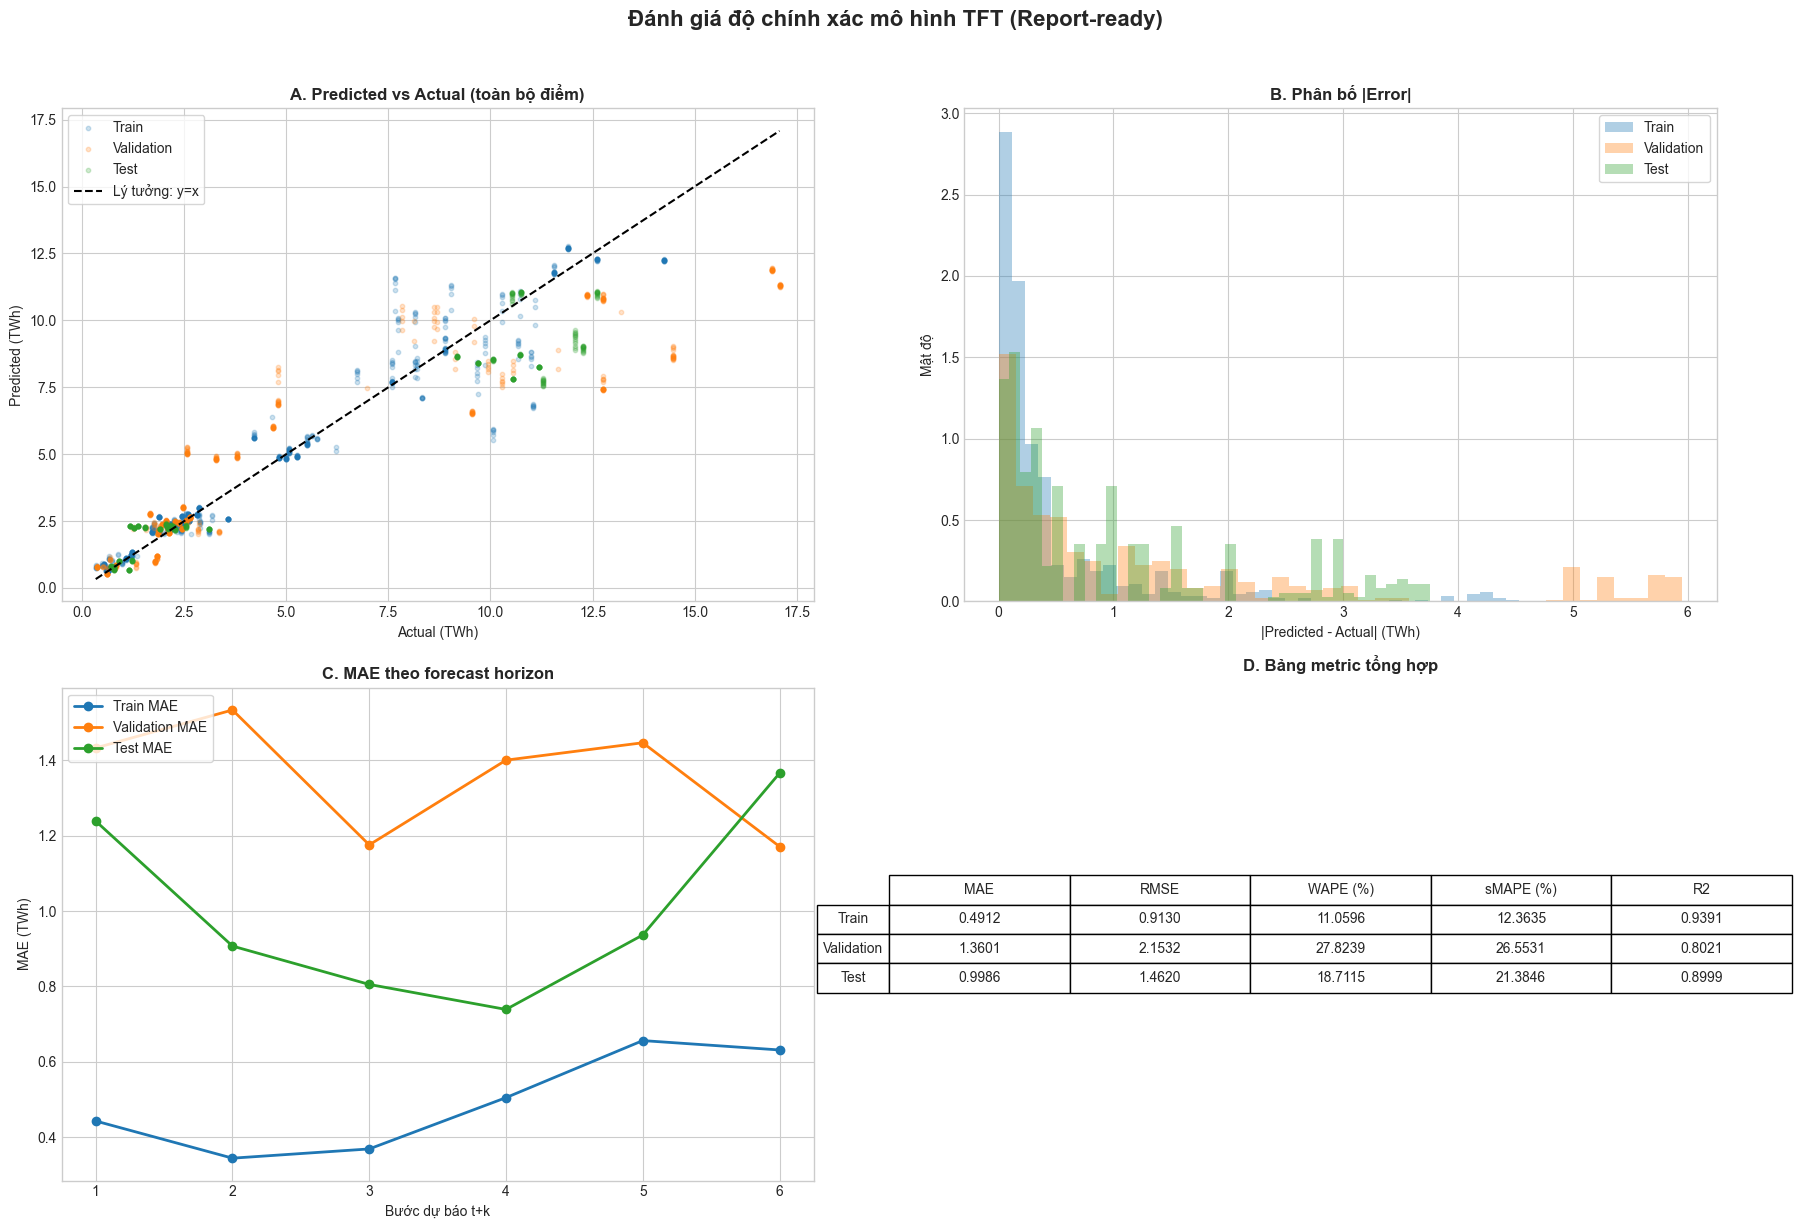

In [55]:
# ── Cell 10: Bộ biểu đồ báo cáo độ chính xác mô hình ───────────────────────────
try:
    plt.style.use('seaborn-v0_8-whitegrid')

    split_cfg = {
        'Train': {'eval': train_eval, 'color': '#1f77b4'},
        'Validation': {'eval': val_eval, 'color': '#ff7f0e'},
        'Test': {'eval': test_eval, 'color': '#2ca02c'},
    }

    def _flatten_eval(eval_dict):
        actual = eval_dict.get('actual_eval')
        pred = eval_dict.get('pred_eval')
        if actual is None or pred is None:
            return None, None
        if isinstance(actual, torch.Tensor):
            actual_np = actual.detach().cpu().numpy()
        else:
            actual_np = np.asarray(actual)
        if isinstance(pred, torch.Tensor):
            pred_np = pred.detach().cpu().numpy()
        else:
            pred_np = np.asarray(pred)

        actual_np = np.asarray(actual_np)
        pred_np = np.asarray(pred_np)
        if actual_np.ndim == 1:
            actual_np = actual_np.reshape(-1, 1)
        if pred_np.ndim == 1:
            pred_np = pred_np.reshape(-1, 1)

        n_sample = min(actual_np.shape[0], pred_np.shape[0])
        n_horizon = min(actual_np.shape[1], pred_np.shape[1])
        actual_np = actual_np[:n_sample, :n_horizon]
        pred_np = pred_np[:n_sample, :n_horizon]

        y_true = actual_np.reshape(-1)
        y_pred = pred_np.reshape(-1)
        valid = np.isfinite(y_true) & np.isfinite(y_pred)
        y_true = y_true[valid]
        y_pred = y_pred[valid]

        return (y_true, y_pred), (actual_np, pred_np)

    processed = {}
    for split_name, cfg in split_cfg.items():
        flattened, matrix_pair = _flatten_eval(cfg['eval'])
        if flattened is None:
            raise ValueError(f'Thiếu dữ liệu để vẽ cho split {split_name}.')
        y_true, y_pred = flattened
        actual_mat, pred_mat = matrix_pair
        err = y_pred - y_true
        abs_err = np.abs(err)
        ape = np.abs(err) / (np.abs(y_true) + 1e-8) * 100

        h_mae = np.mean(np.abs(pred_mat - actual_mat), axis=0)
        h_smape = np.mean(2.0 * np.abs(pred_mat - actual_mat) / (np.abs(actual_mat) + np.abs(pred_mat) + 1e-8), axis=0) * 100

        processed[split_name] = {
            'y_true': y_true,
            'y_pred': y_pred,
            'abs_err': abs_err,
            'ape': ape,
            'h_mae': h_mae,
            'h_smape': h_smape,
            'metrics': cfg['eval']['metrics'],
            'color': cfg['color'],
        }

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # (1) Scatter: Predicted vs Actual + đường lý tưởng y=x
    ax = axes[0, 0]
    all_true = []
    all_pred = []
    for split_name, d in processed.items():
        all_true.append(d['y_true'])
        all_pred.append(d['y_pred'])
        max_points = min(4000, len(d['y_true']))
        if len(d['y_true']) > max_points:
            idx = np.random.choice(len(d['y_true']), max_points, replace=False)
            x_plot = d['y_true'][idx]
            y_plot = d['y_pred'][idx]
        else:
            x_plot = d['y_true']
            y_plot = d['y_pred']
        ax.scatter(x_plot, y_plot, s=10, alpha=0.22, color=d['color'], label=split_name)

    all_true = np.concatenate(all_true)
    all_pred = np.concatenate(all_pred)
    lim_min = float(np.nanmin([all_true.min(), all_pred.min()]))
    lim_max = float(np.nanmax([all_true.max(), all_pred.max()]))
    ax.plot([lim_min, lim_max], [lim_min, lim_max], '--', color='black', linewidth=1.5, label='Lý tưởng: y=x')
    ax.set_title('A. Predicted vs Actual (toàn bộ điểm)', fontweight='bold')
    ax.set_xlabel('Actual (TWh)')
    ax.set_ylabel('Predicted (TWh)')
    ax.legend(loc='upper left', frameon=True)

    # (2) Phân bố sai số tuyệt đối
    ax = axes[0, 1]
    bins = 40
    for split_name, d in processed.items():
        ax.hist(d['abs_err'], bins=bins, alpha=0.35, density=True, color=d['color'], label=split_name)
    ax.set_title('B. Phân bố |Error|', fontweight='bold')
    ax.set_xlabel('|Predicted - Actual| (TWh)')
    ax.set_ylabel('Mật độ')
    ax.legend(loc='upper right', frameon=True)

    # (3) Sai số theo từng bước forecast horizon
    ax = axes[1, 0]
    for split_name, d in processed.items():
        x_h = np.arange(1, len(d['h_mae']) + 1)
        ax.plot(x_h, d['h_mae'], marker='o', linewidth=2.0, color=d['color'], label=f'{split_name} MAE')
    ax.set_title('C. MAE theo forecast horizon', fontweight='bold')
    ax.set_xlabel('Bước dự báo t+k')
    ax.set_ylabel('MAE (TWh)')
    ax.legend(loc='upper left', frameon=True)

    # (4) Bảng metric tóm tắt cho báo cáo
    ax = axes[1, 1]
    ax.axis('off')
    metric_rows = []
    row_labels = []
    for split_name, d in processed.items():
        m = d['metrics']
        row_labels.append(split_name)
        metric_rows.append([m['mae'], m['rmse'], m['wape'], m['smape'], m['r2']])

    col_labels = ['MAE', 'RMSE', 'WAPE (%)', 'sMAPE (%)', 'R2']
    table = ax.table(
        cellText=[[f'{v:.4f}' for v in row] for row in metric_rows],
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center',
        rowLoc='center',
        loc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    ax.set_title('D. Bảng metric tổng hợp', fontweight='bold', pad=12)

    fig.suptitle('Đánh giá độ chính xác mô hình TFT (Report-ready)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

except Exception as exc:
    print(f'Plot error: {exc}')

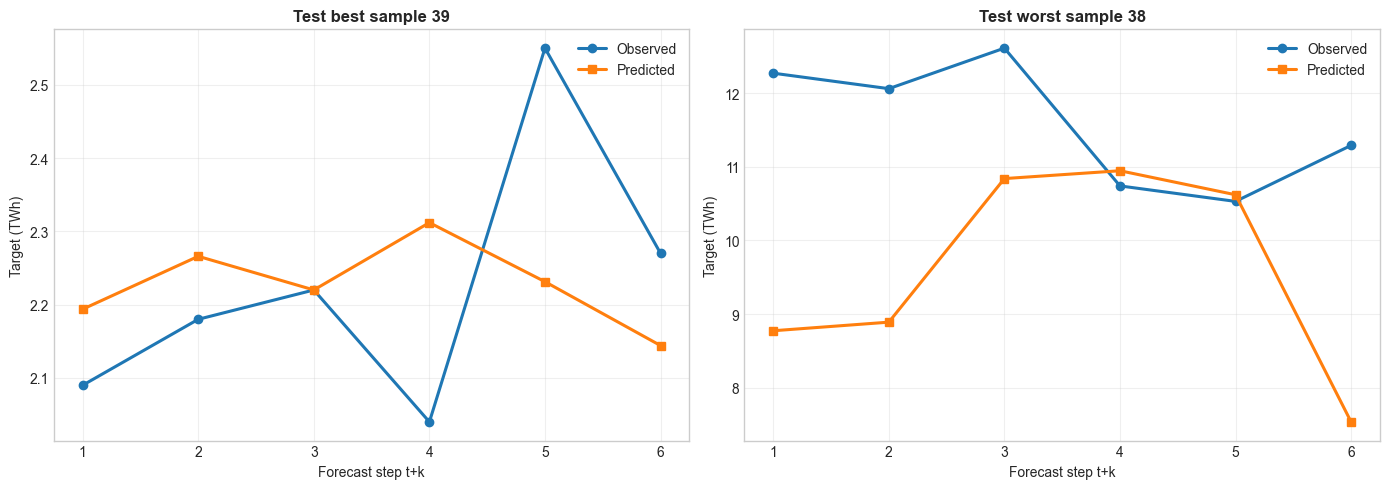

In [56]:
# ── Cell 11: Diagnostic plot clean (forecast + attention heatmap) ─────────────
try:
    test_actual = test_eval.get('actual_eval')
    test_pred = test_eval.get('pred_eval')

    if test_actual is None or test_pred is None:
        raise ValueError('Thiếu test_eval để vẽ diagnostic plot.')

    if not isinstance(test_actual, torch.Tensor):
        test_actual = torch.as_tensor(test_actual)
    if not isinstance(test_pred, torch.Tensor):
        test_pred = torch.as_tensor(test_pred)

    if test_actual.ndim == 1:
        test_actual = test_actual.unsqueeze(1)
    if test_pred.ndim == 1:
        test_pred = test_pred.unsqueeze(1)

    n_sample = min(test_actual.shape[0], test_pred.shape[0])
    n_horizon = min(test_actual.shape[1], test_pred.shape[1])
    test_actual = test_actual[:n_sample, :n_horizon]
    test_pred = test_pred[:n_sample, :n_horizon]

    sample_mae = (test_actual - test_pred).abs().mean(dim=1)
    best_idx = int(torch.argmin(sample_mae).item())
    worst_idx = int(torch.argmax(sample_mae).item())

    def _plot_clean_forecast(ax, actual_tensor, pred_tensor, idx, title):
        actual_np = actual_tensor[idx].detach().cpu().numpy()
        pred_np = pred_tensor[idx].detach().cpu().numpy()
        horizon = min(len(actual_np), len(pred_np))
        x_axis = np.arange(1, horizon + 1)
        ax.plot(x_axis, actual_np[:horizon], marker='o', linewidth=2.2, label='Observed')
        ax.plot(x_axis, pred_np[:horizon], marker='s', linewidth=2.2, label='Predicted')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Forecast step t+k')
        ax.set_ylabel('Target (TWh)')
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    _plot_clean_forecast(axes[0], test_actual, test_pred, best_idx, f'Test best sample {best_idx}')
    _plot_clean_forecast(axes[1], test_actual, test_pred, worst_idx, f'Test worst sample {worst_idx}')
    plt.tight_layout()
    plt.show()

    # Attention hiển thị riêng dạng heatmap (nếu model trả về).
    raw_obj = plot_test_raw_predictions
    attention = None
    if hasattr(raw_obj, 'attention'):
        attention = raw_obj.attention
    elif isinstance(raw_obj, dict) and 'attention' in raw_obj:
        attention = raw_obj['attention']

    if attention is not None:
        if not isinstance(attention, torch.Tensor):
            attention = torch.as_tensor(attention)
        if attention.ndim >= 3:
            # Thông dụng: [batch, decoder_steps, encoder_steps]
            att_best = attention[best_idx].detach().cpu().numpy()
            if att_best.ndim == 2:
                att_plot = att_best
            else:
                att_plot = np.mean(att_best, axis=0)
        else:
            att_plot = attention.detach().cpu().numpy()

        fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
        im = ax.imshow(att_plot, aspect='auto', cmap='viridis')
        ax.set_title(f'Attention heatmap (best sample {best_idx})', fontweight='bold')
        ax.set_xlabel('Encoder time step')
        ax.set_ylabel('Decoder step')
        plt.colorbar(im, ax=ax, label='Attention weight')
        plt.tight_layout()
        plt.show()

except Exception as exc:
    print(f'Diagnostic plot error: {exc}')

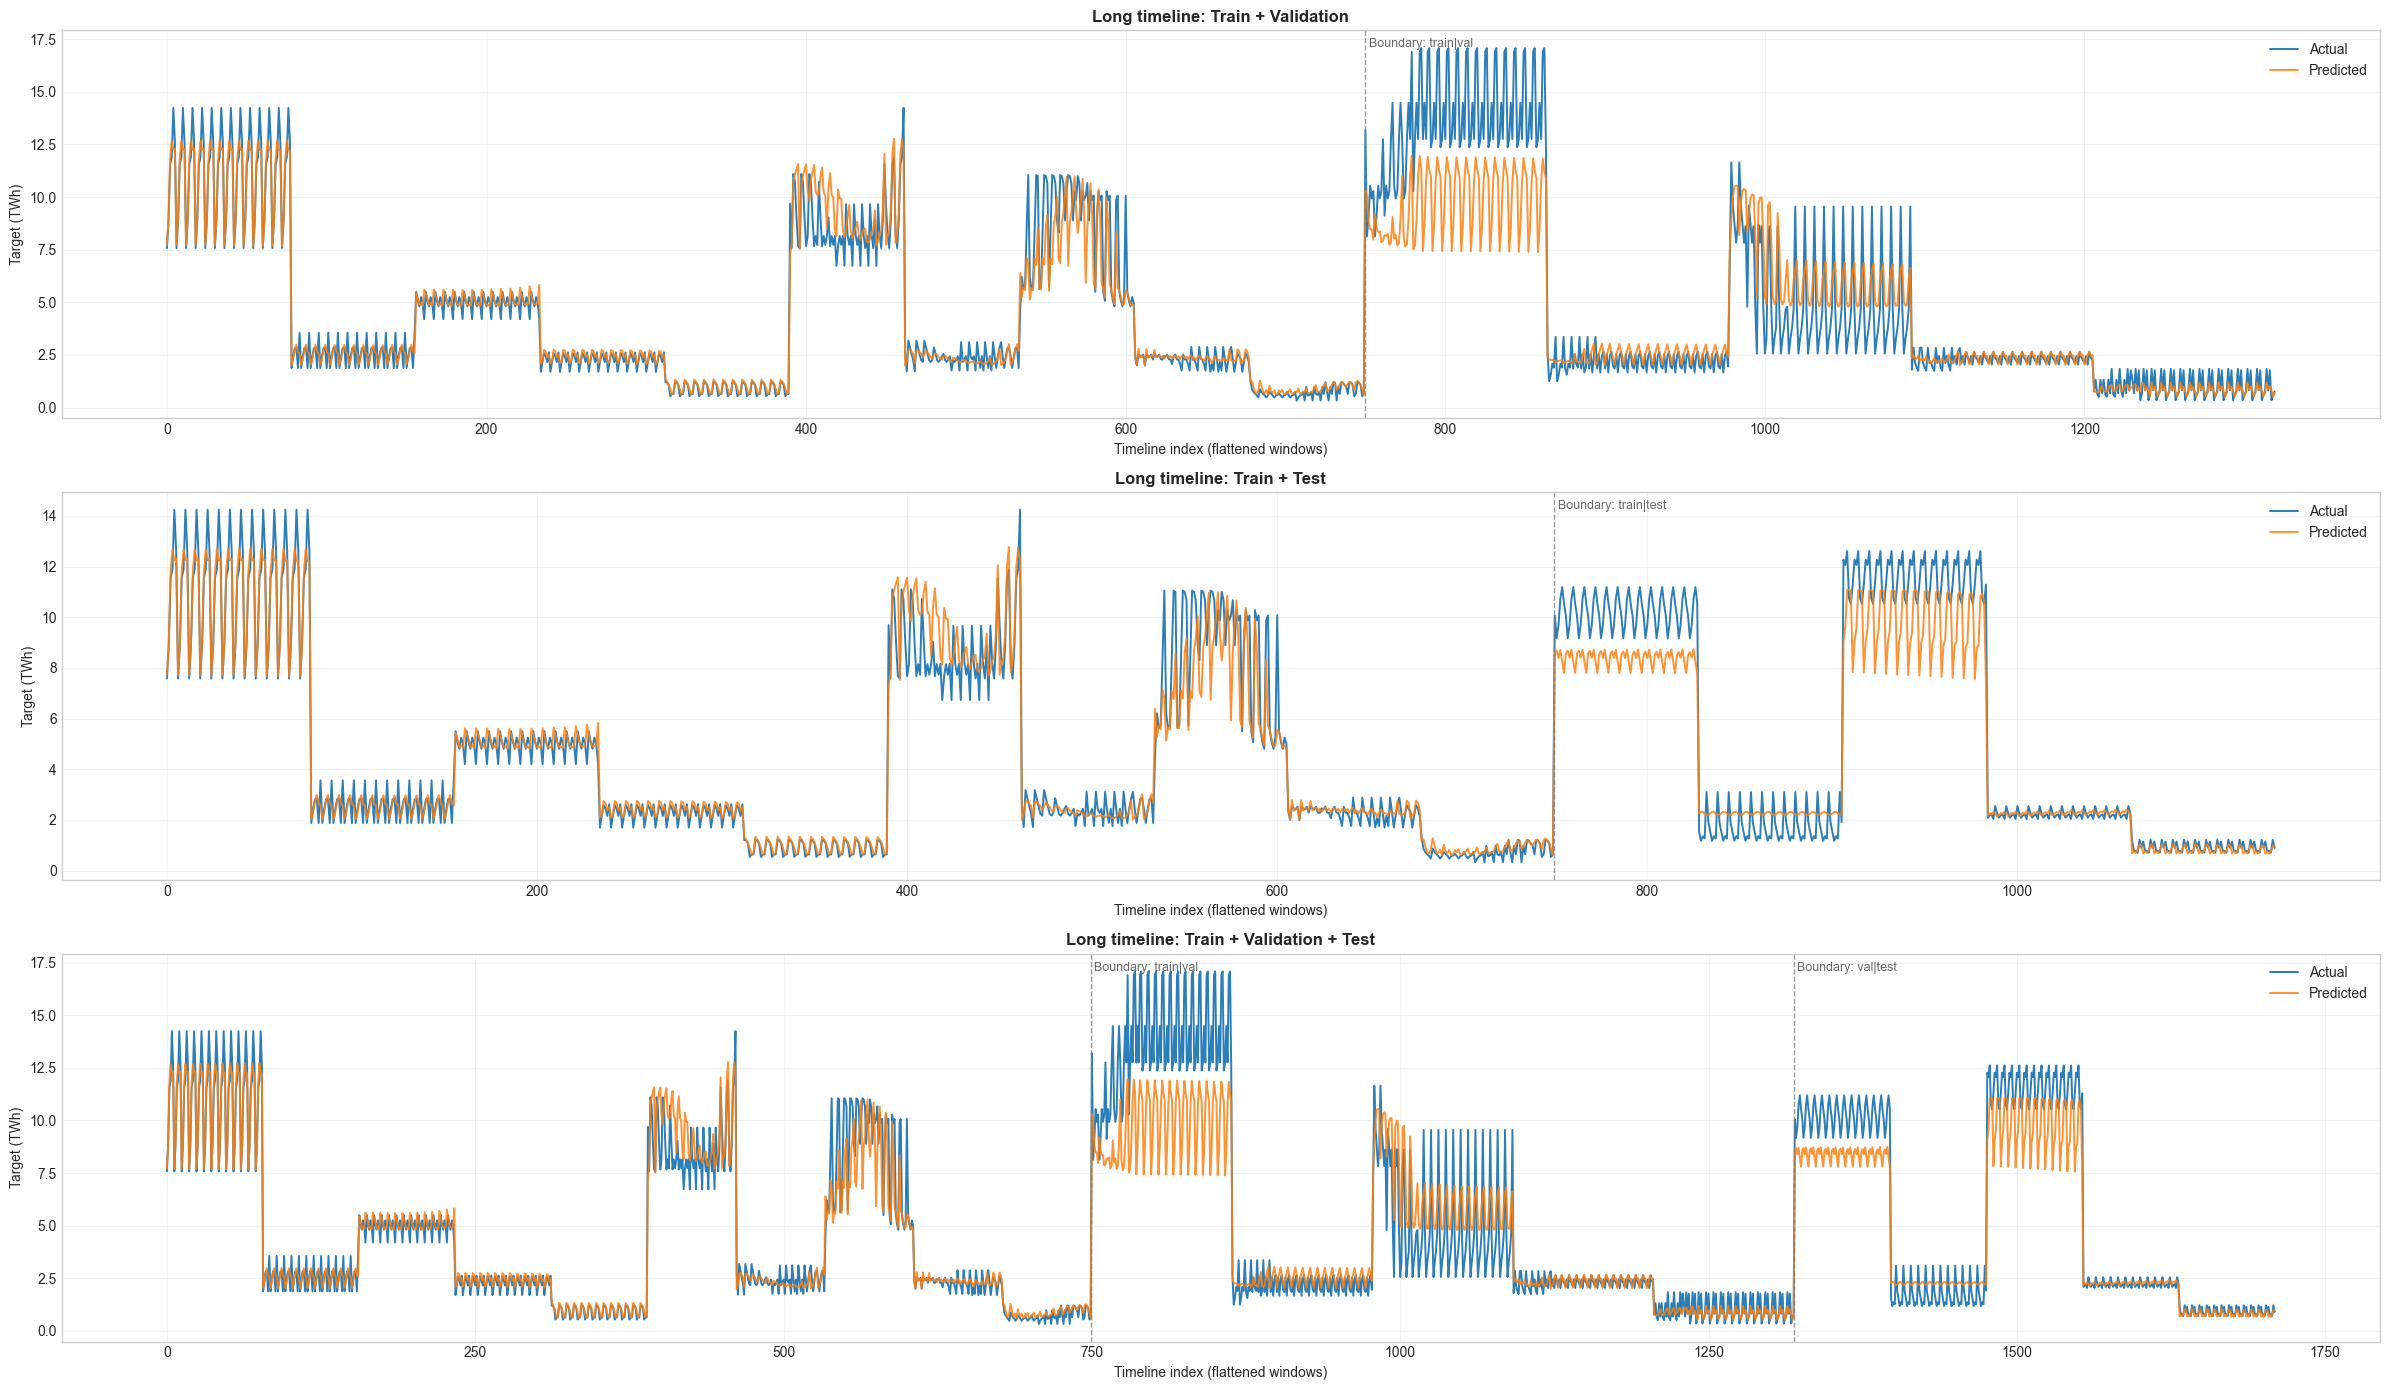

In [57]:
# ── Cell 12: Long timeline như cũ (Train+Val, Train+Test, Full) ───────────────
try:
    train_actual = train_eval.get('actual_eval')
    train_pred = train_eval.get('pred_eval')
    val_actual = val_eval.get('actual_eval')
    val_pred = val_eval.get('pred_eval')
    test_actual = test_eval.get('actual_eval')
    test_pred = test_eval.get('pred_eval')

    def _to_1d_numpy(tensor_like):
        if tensor_like is None:
            return None
        if isinstance(tensor_like, torch.Tensor):
            arr = tensor_like.detach().cpu().numpy()
        else:
            arr = np.asarray(tensor_like)
        return arr.reshape(-1)

    def _align_pair(actual_1d, pred_1d):
        if actual_1d is None or pred_1d is None:
            return None, None
        n = min(len(actual_1d), len(pred_1d))
        if n == 0:
            return None, None
        return actual_1d[:n], pred_1d[:n]

    train_a, train_p = _align_pair(_to_1d_numpy(train_actual), _to_1d_numpy(train_pred))
    val_a, val_p = _align_pair(_to_1d_numpy(val_actual), _to_1d_numpy(val_pred))
    test_a, test_p = _align_pair(_to_1d_numpy(test_actual), _to_1d_numpy(test_pred))

    if any(x is None for x in [train_a, train_p, val_a, val_p, test_a, test_p]):
        raise ValueError('Không đủ dữ liệu để vẽ biểu đồ timeline cho một hoặc nhiều split.')

    tv_a = np.concatenate([train_a, val_a])
    tv_p = np.concatenate([train_p, val_p])
    tt_a = np.concatenate([train_a, test_a])
    tt_p = np.concatenate([train_p, test_p])
    full_a = np.concatenate([train_a, val_a, test_a])
    full_p = np.concatenate([train_p, val_p, test_p])

    def _plot_long(ax, actual_series, pred_series, title, boundaries=None):
        x = np.arange(len(actual_series))
        ax.plot(x, actual_series, label='Actual', linewidth=1.4, alpha=0.95)
        ax.plot(x, pred_series, label='Predicted', linewidth=1.4, alpha=0.85)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Timeline index (flattened windows)')
        ax.set_ylabel('Target (TWh)')
        ax.grid(True, alpha=0.25)
        if boundaries is not None:
            for b, label in boundaries:
                ax.axvline(b - 0.5, color='gray', linestyle='--', linewidth=1.0, alpha=0.8)
                y_top = ax.get_ylim()[1]
                ax.text(b + 2, y_top * 0.98, label, fontsize=9, color='dimgray', va='top')
        ax.legend(loc='upper right')

    fig, axes = plt.subplots(3, 1, figsize=(24, 14), sharex=False)

    _plot_long(
        axes[0],
        tv_a,
        tv_p,
        'Long timeline: Train + Validation',
        boundaries=[(len(train_a), 'Boundary: train|val')],
    )

    _plot_long(
        axes[1],
        tt_a,
        tt_p,
        'Long timeline: Train + Test',
        boundaries=[(len(train_a), 'Boundary: train|test')],
    )

    _plot_long(
        axes[2],
        full_a,
        full_p,
        'Long timeline: Train + Validation + Test',
        boundaries=[
            (len(train_a), 'Boundary: train|val'),
            (len(train_a) + len(val_a), 'Boundary: val|test'),
        ],
    )

    plt.tight_layout()
    plt.show()

except Exception as exc:
    print(f'Long timeline plot error: {exc}')

In [58]:
# ── Cell 13: Root-cause diagnostics (vì sao Validation tệ hơn Test) ───────────
try:
    import numpy as np
    import pandas as pd

    def _to_np_2d(x):
        if isinstance(x, torch.Tensor):
            arr = x.detach().cpu().numpy()
        else:
            arr = np.asarray(x)
        if arr.ndim == 1:
            arr = arr.reshape(-1, 1)
        return arr

    def _flatten_pair(eval_dict):
        a = _to_np_2d(eval_dict['actual_eval'])
        p = _to_np_2d(eval_dict['pred_eval'])
        n0 = min(a.shape[0], p.shape[0])
        n1 = min(a.shape[1], p.shape[1])
        a = a[:n0, :n1]
        p = p[:n0, :n1]
        y_true = a.reshape(-1)
        y_pred = p.reshape(-1)
        e = y_pred - y_true
        return a, p, y_true, y_pred, e

    tr_a, tr_p, tr_y, tr_hat, tr_e = _flatten_pair(train_eval)
    va_a, va_p, va_y, va_hat, va_e = _flatten_pair(val_eval)
    te_a, te_p, te_y, te_hat, te_e = _flatten_pair(test_eval)

    def _summary(name, y, yhat, e):
        abs_e = np.abs(e)
        ape = abs_e / (np.abs(y) + 1e-8) * 100
        q = np.quantile(abs_e, [0.5, 0.75, 0.9, 0.95, 0.99])
        return {
            'split': name,
            'n_points': len(y),
            'mean_y': float(np.mean(y)),
            'std_y': float(np.std(y)),
            'mean_pred': float(np.mean(yhat)),
            'bias_mean(pred-true)': float(np.mean(e)),
            'MAE': float(np.mean(abs_e)),
            'RMSE': float(np.sqrt(np.mean(e ** 2))),
            'APE_mean(%)': float(np.mean(ape)),
            'AE_p50': float(q[0]),
            'AE_p75': float(q[1]),
            'AE_p90': float(q[2]),
            'AE_p95': float(q[3]),
            'AE_p99': float(q[4]),
        }

    rows = [
        _summary('Train', tr_y, tr_hat, tr_e),
        _summary('Validation', va_y, va_hat, va_e),
        _summary('Test', te_y, te_hat, te_e),
    ]
    diag_df = pd.DataFrame(rows)
    print('=== Split-level distribution & error summary ===')
    print(diag_df.to_string(index=False))

    print('\n=== Horizon MAE (Validation vs Test) ===')
    h_val = np.mean(np.abs(va_p - va_a), axis=0)
    h_test = np.mean(np.abs(te_p - te_a), axis=0)
    h_df = pd.DataFrame({
        'horizon': np.arange(1, len(h_val) + 1),
        'val_mae': h_val,
        'test_mae': h_test,
        'ratio_val_over_test': h_val / (h_test + 1e-8),
    })
    print(h_df.to_string(index=False))

    # Nếu có series_metrics thì so nhanh top series khó giữa Val/Test
    if val_eval.get('series_metrics') is not None and test_eval.get('series_metrics') is not None:
        vsm = val_eval['series_metrics'][['series', 'mae', 'wape', 'smape']].copy()
        tsm = test_eval['series_metrics'][['series', 'mae', 'wape', 'smape']].copy()
        vsm = vsm.rename(columns={'mae': 'val_mae', 'wape': 'val_wape', 'smape': 'val_smape'})
        tsm = tsm.rename(columns={'mae': 'test_mae', 'wape': 'test_wape', 'smape': 'test_smape'})
        merged = vsm.merge(tsm, on='series', how='inner')
        merged['delta_mae(val-test)'] = merged['val_mae'] - merged['test_mae']
        merged = merged.sort_values('delta_mae(val-test)', ascending=False)
        print('\n=== Top 10 series khiến Validation tệ hơn Test (theo delta MAE) ===')
        print(merged.head(10).to_string(index=False))

except Exception as exc:
    print(f'Diagnostic analysis error: {exc}')

=== Split-level distribution & error summary ===
     split  n_points   mean_y    std_y  mean_pred  bias_mean(pred-true)      MAE     RMSE  APE_mean(%)   AE_p50   AE_p75   AE_p90   AE_p95   AE_p99
     Train       750 4.441373 3.701219   4.449474              0.008100 0.491196 0.913019    13.671206 0.180115 0.465127 1.406147 2.022315 4.209842
Validation       570 4.888280 4.840361   4.390207             -0.498073 1.360112 2.153211    28.618204 0.643781 1.884068 4.997163 5.510667 5.861996
      Test       390 5.337000 4.620421   4.713207             -0.623793 0.998632 1.462036    22.714333 0.495840 1.525658 2.946909 3.282246 3.651130

=== Horizon MAE (Validation vs Test) ===
 horizon  val_mae  test_mae  ratio_val_over_test
       1 1.433010  1.238690             1.156875
       2 1.533653  0.906979             1.690946
       3 1.175601  0.805154             1.460095
       4 1.400489  0.738766             1.895714
       5 1.446658  0.936418             1.544885
       6 1.171259  1.36

In [59]:
# ── Cell 14: Phân tích regime shift theo mốc thời gian và theo series ──────────
try:
    # Dùng dữ liệu đã tiền xử lý trong df_vn_valid và mốc split hiện tại
    split_map = pd.Series(np.where(
        df_vn_valid['time_idx'] <= train_cutoff, 'Train',
        np.where(df_vn_valid['time_idx'] <= val_cutoff, 'Validation', 'Test')
    ), index=df_vn_valid.index)

    temp = df_vn_valid[['entity', 'series', 'date', 'time_idx', 'generation_TWh']].copy()
    temp['split'] = split_map.values

    if LOG_TRANSFORM:
        temp['target_twh'] = np.expm1(temp['generation_TWh']).clip(lower=0)
    else:
        temp['target_twh'] = temp['generation_TWh']

    print('=== Time ranges by split ===')
    print(
        temp.groupby('split')['date']
            .agg(['min', 'max', 'count'])
            .reindex(['Train', 'Validation', 'Test'])
            .to_string()
    )

    stat = (
        temp.groupby(['split', 'series'])['target_twh']
            .agg(['mean', 'std', 'min', 'max', 'count'])
            .reset_index()
    )
    piv_mean = stat.pivot(index='series', columns='split', values='mean')
    piv_std = stat.pivot(index='series', columns='split', values='std')

    for col in ['Train', 'Validation', 'Test']:
        if col not in piv_mean.columns:
            piv_mean[col] = np.nan
        if col not in piv_std.columns:
            piv_std[col] = np.nan

    shift_df = pd.DataFrame({
        'series': piv_mean.index,
        'mean_train': piv_mean['Train'].values,
        'mean_val': piv_mean['Validation'].values,
        'mean_test': piv_mean['Test'].values,
        'std_train': piv_std['Train'].values,
        'std_val': piv_std['Validation'].values,
        'std_test': piv_std['Test'].values,
    })
    shift_df['val_over_train_mean'] = shift_df['mean_val'] / (shift_df['mean_train'] + 1e-8)
    shift_df['test_over_train_mean'] = shift_df['mean_test'] / (shift_df['mean_train'] + 1e-8)
    shift_df['val_over_test_mean'] = shift_df['mean_val'] / (shift_df['mean_test'] + 1e-8)
    shift_df['val_over_test_std'] = shift_df['std_val'] / (shift_df['std_test'] + 1e-8)

    print('\n=== Series shift summary (sorted by val/test mean ratio) ===')
    print(shift_df.sort_values('val_over_test_mean', ascending=False).to_string(index=False))

except Exception as exc:
    print(f'Regime shift diagnostic error: {exc}')

=== Time ranges by split ===
                  min        max  count
split                                  
Train      2019-01-01 2023-06-01    270
Validation 2023-07-01 2024-06-01     60
Test       2024-07-01 2024-12-01     30

=== Series shift summary (sorted by val/test mean ratio) ===
series  mean_train  mean_val  mean_test  std_train  std_val  std_test  val_over_train_mean  test_over_train_mean  val_over_test_mean  val_over_test_std
   Gas    2.841852  2.154167   1.725000   0.754486 0.582541  0.721131             0.758015              0.606999            1.248792           0.807815
  Coal    9.804630 12.294167  10.230000   1.799438 2.864639  0.733648             1.253914              1.043385            1.201776           3.904648
  Wind    0.348537  0.948333   0.921667   0.369875 0.492800  0.214235             2.720897              2.644387            1.028933           2.300275
 Solar    1.519265  2.264167   2.225000   0.966650 0.378501  0.180083             1.490304           

In [60]:
# ── Cell 15: Thử nghiệm scalar calibration từ Train+Validation (không dùng Test) ─
try:
    def _flat_np(ev):
        a = ev['actual_eval'].reshape(-1).detach().cpu().numpy()
        p = ev['pred_eval'].reshape(-1).detach().cpu().numpy()
        m = np.isfinite(a) & np.isfinite(p)
        return a[m], p[m]

    tr_y, tr_p = _flat_np(train_eval)
    va_y, va_p = _flat_np(val_eval)
    te_y, te_p = _flat_np(test_eval)

    y_cal = np.concatenate([tr_y, va_y])
    p_cal = np.concatenate([tr_p, va_p])
    alpha = float(np.sum(y_cal * p_cal) / (np.sum(p_cal * p_cal) + 1e-10))
    alpha = float(np.clip(alpha, 0.85, 1.30))

    def _metric(y, p):
        e = p - y
        mae = float(np.mean(np.abs(e)))
        rmse = float(np.sqrt(np.mean(e ** 2)))
        smape = float(np.mean(2*np.abs(e)/(np.abs(y)+np.abs(p)+1e-8))*100)
        return mae, rmse, smape, float(np.mean(e))

    va_before = _metric(va_y, va_p)
    te_before = _metric(te_y, te_p)
    va_after = _metric(va_y, np.clip(alpha * va_p, 0, None))
    te_after = _metric(te_y, np.clip(alpha * te_p, 0, None))

    print(f'alpha(train+val) = {alpha:.5f}')
    print('Val before -> after (MAE, RMSE, sMAPE, bias):', va_before, '->', va_after)
    print('Test before -> after (MAE, RMSE, sMAPE, bias):', te_before, '->', te_after)

except Exception as exc:
    print(f'Scalar trial error: {exc}')

alpha(train+val) = 1.07790
Val before -> after (MAE, RMSE, sMAPE, bias): (1.3601115942001343, 2.1532113552093506, 26.55307960510254, -0.49807295203208923) -> (1.3331726789474487, 1.9816211462020874, 27.6844539642334, -0.15608087182044983)
Test before -> after (MAE, RMSE, sMAPE, bias): (0.9986319541931152, 1.4620364904403687, 21.38456916809082, -0.6237925887107849) -> (0.8811367154121399, 1.1981738805770874, 21.184539794921875, -0.25663915276527405)
